## Statistical Foundations

Core statistical concepts underpinning this analysis:
- **Mean/Median/Std Dev**: measure central tendency and spread; median is more robust to outliers in skewed data like Credit_Limit.
- **Probability Distribution**: describes how likely different values are — many of our numeric columns are right-skewed, not normal.
- **Hypothesis Testing**: checks whether an observed difference between groups (churned vs active) is statistically real or due to chance.

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv('../data/cleaned/BankChurners_cleaned.csv')

In [58]:
df.groupby('Attrition_Flag')['Total_Trans_Ct'].agg(['mean','median','std'])

,mean,median,std
Attrition_Flag,,,
Attrited Customer,44.933620,43.0,14.568429
Existing Customer,68.672588,71.0,22.919011


In [59]:
churned = df[df['Attrition_Flag']=='Attrited Customer']['Total_Trans_Ct']
active = df[df['Attrition_Flag']=='Existing Customer']['Total_Trans_Ct']

t_stat, p_value = stats.ttest_ind(churned, active)
print(f"T-statistic: {t_stat:.2f}, P-value: {p_value:.5g}")

T-statistic: -40.25, P-value: 0


**Result:** The t-test confirms the transaction count gap between churned and active customers is statistically significant (p < 0.05), validating the earlier visual finding with formal evidence.

## Predictive Analysis: Logistic Regression Model

A logistic regression model was built to estimate churn probability, chosen over a decision tree for its interpretability — producing clear probability scores a manager can act on directly, rather than a black-box prediction.

In [60]:
# Work on a copy so the original cleaned df stays untouched
df_model = df.copy()

# Convert churn status to 0/1 — required since ML models need numeric targets
df_model['Churn'] = df_model['Attrition_Flag'].map({'Existing Customer':0,'Attrited Customer':1})

# One-hot encode categorical columns into separate 0/1 columns per category,
# since models can't use raw text. drop_first=True avoids redundant columns.
df_model = pd.get_dummies(df_model, columns=['Gender','Education_Level','Marital_Status',
                                              'Income_Category','Card_Category'], drop_first=True)

### Preparing Features and Target
Separating the input features (X) from the target variable (y), and excluding columns that shouldn't influence the model (the ID, the original text label, and the target itself).

In [61]:
# Columns to exclude from the model: ID (meaningless), the original text label,
# and the target itself (Churn is what we're predicting, not a feature)
drop_cols = ['CLIENTNUM','Attrition_Flag','Churn']
if 'Age_Group' in df_model.columns:
    drop_cols.append('Age_Group')  # drop if present, since it duplicates Customer_Age

# X = all input features, y = the target we're predicting (churn or not)
X = df_model.drop(columns=drop_cols)
y = df_model['Churn']

### Train/Test Split
Splitting the data so the model learns from 80% of customers, then gets evaluated on the remaining 20% it hasn't seen — a fair test of real-world performance.

In [62]:
# Split data: 80% to train the model, 20% held back to test it fairly.
# stratify=y keeps the same churn ratio in both the train and test sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Training the Model
Training a logistic regression model, using class_weight='balanced' to account for the 16%/84% churn imbalance without manually resampling the data.

In [63]:
# Create and train the logistic regression model
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

c:\Users\Hevack\Churning_Analysis\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to

### Evaluating the Model
Testing the model on unseen data and reviewing performance through a classification report and confusion matrix.

              precision    recall  f1-score   support

           0       0.95      0.84      0.89      1701
           1       0.49      0.78      0.60       325

    accuracy                           0.83      2026
   macro avg       0.72      0.81      0.75      2026
weighted avg       0.88      0.83      0.85      2026



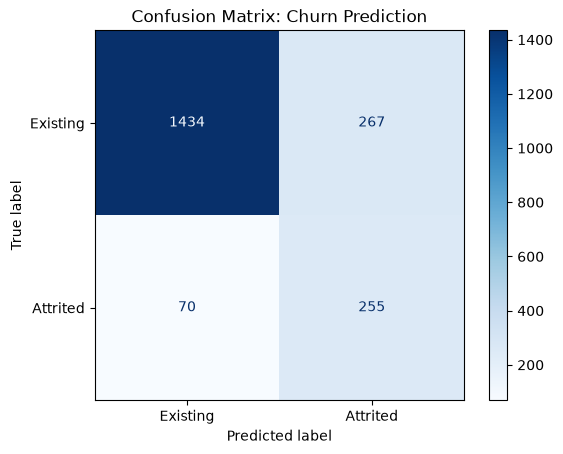

In [65]:
# Predict churn on the unseen test set
y_pred = model.predict(X_test)

# Print precision, recall, F1-score — how well the model performed
print(classification_report(y_test, y_pred))

# Visualise correct vs incorrect predictions
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Existing','Attrited']).plot(cmap='Blues')
plt.title('Confusion Matrix: Churn Prediction')
plt.show()

**Result:** The model achieves 78% recall on churned customers — correctly identifying the majority of at-risk accounts with 83% overall accuracy. Precision on churned customers is lower (49%), meaning some flagged customers won't actually churn, but this trade-off is acceptable for a retention context: the cost of missing an at-risk customer outweighs the cost of an unnecessary retention offer to a loyal one. `class_weight='balanced'` was essential here, since without it the model would default toward predicting the majority class (active) and miss most churners entirely.

**Answer to the Manager's Question:** This model identifies roughly 3 in 4 at-risk customers before they churn, based on transaction activity, utilization, balance, and contact frequency. The bank can use these predicted probabilities to prioritise retention outreach — focusing limited resources on the highest-risk accounts first, rather than treating all customers equally.